# Figures

In [1]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt

### Classification task example

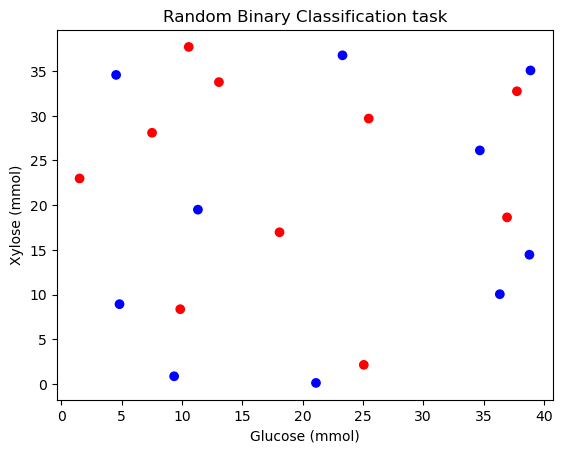

In [ ]:
# Load data
with open(f"perf_datasets/iML1515_GX.pkl", "rb") as f:
    data = pickle.load(f)

templates = data["templates"]

# Set seed for reproducibility
np.random.seed(23)

# Assign random red or blue to each point (independent of neighbors)
point_colors = ['red' if np.random.rand() > 0.5 else 'blue' for _ in range(len(templates))]

# Plot
plt.scatter(templates[:, 0], templates[:, 1], c=point_colors, alpha=1)
plt.xlabel("Glucose (mmol)")
plt.ylabel("Xylose (mmol)")
plt.title("Random Binary Classification task")
plt.savefig('figures/classification_task.pdf')
plt.show()

### Noisy samples visualization

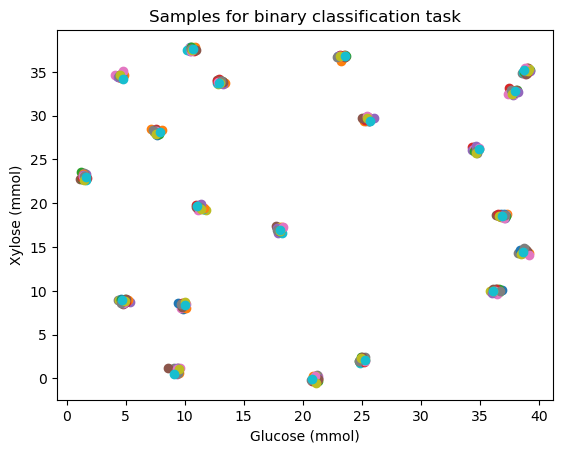

In [ ]:
# Load data
with open(f"perf_datasets/iML1515_GX.pkl", "rb") as f:
    data = pickle.load(f)

samples = data["train_samples"]

for sample in samples:
    plt.scatter(sample[0],sample[1])
plt.xlabel("Glucose (mmol)")
plt.ylabel("Xylose (mmol)")
plt.title(f"Samples for binary classification task")
plt.savefig('figures/samples.pdf')

### Evolution of accuracy

Dictionary of model names to species for better figure interpretation

In [7]:
species_names = {
    "iEK1008" : "M. tuberculosis",
    "iIT341" : "H. pylori",
    "iJN1463" : "P. putida",
    "iML1515" : "E. coli",
    "iMM904" : "S. cerevisiae",
    "iPC815" : "Y. pestis",
    "iYO844" : "B. subtilis",
    "iYS1720" : "Salmonella",
    "iYS854" : "S. aureus",
    "iNF517" : "L. lactis"
}

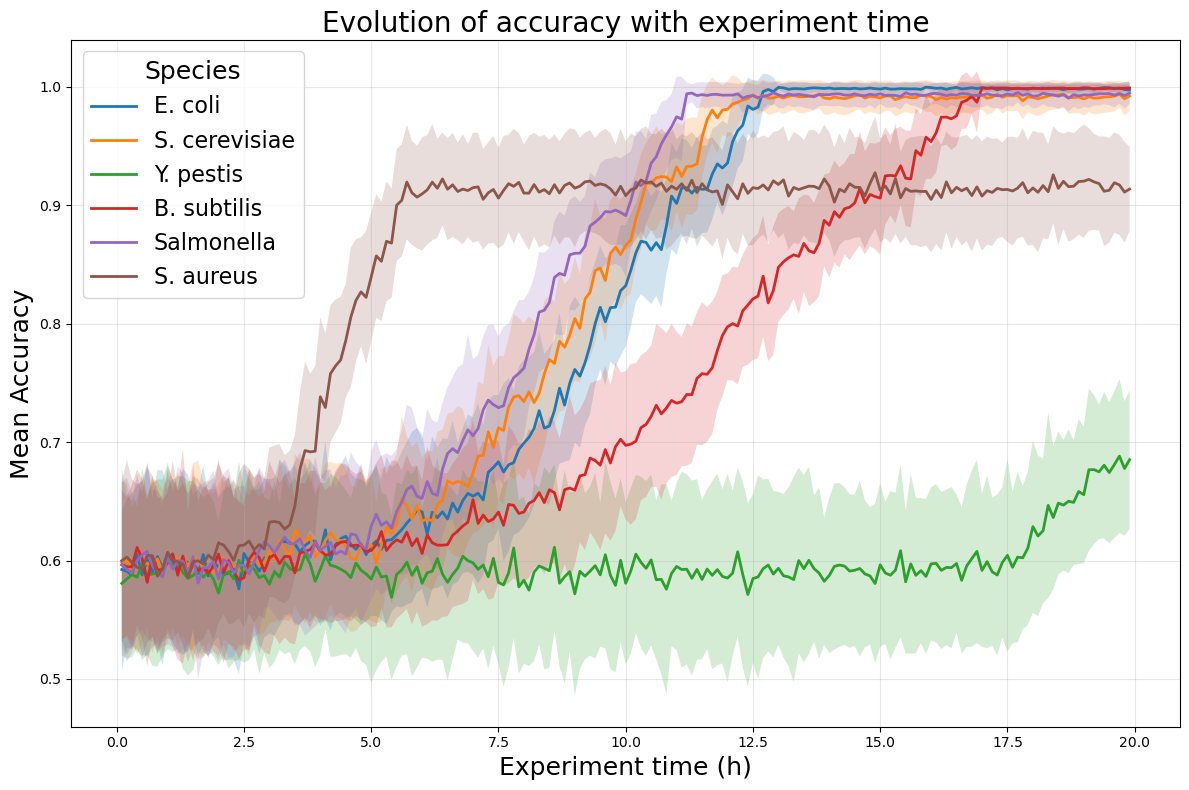

In [8]:
files = [fname for fname in os.listdir("tradeoff_analysis") if fname.endswith("GX.csv")]
plt.figure(figsize=(12, 8))

for file in files:
    results_df = pd.read_csv(f"tradeoff_analysis/{file}")
    # Extract model name
    model_name = file.strip("_GX.csv")
    
    # Plot mean line
    plt.plot(results_df["remaining_timepoints"]/10, results_df["mean_acc_curves"], 
             linewidth=2, label=species_names[model_name])
    
    # Add shaded area for standard deviation
    plt.fill_between(results_df["remaining_timepoints"]/10, 
                     results_df["mean_acc_curves"] - results_df["std_acc_curves"],
                     results_df["mean_acc_curves"] + results_df["std_acc_curves"],
                     alpha=0.2)

plt.xlabel("Experiment time (h)", fontsize=18)
plt.ylabel("Mean Accuracy", fontsize=18)
plt.title("Evolution of accuracy with experiment time", fontsize=20)
plt.legend(loc='upper left', title='Species', title_fontsize=18, fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/acc_species_GX.pdf')
plt.show()

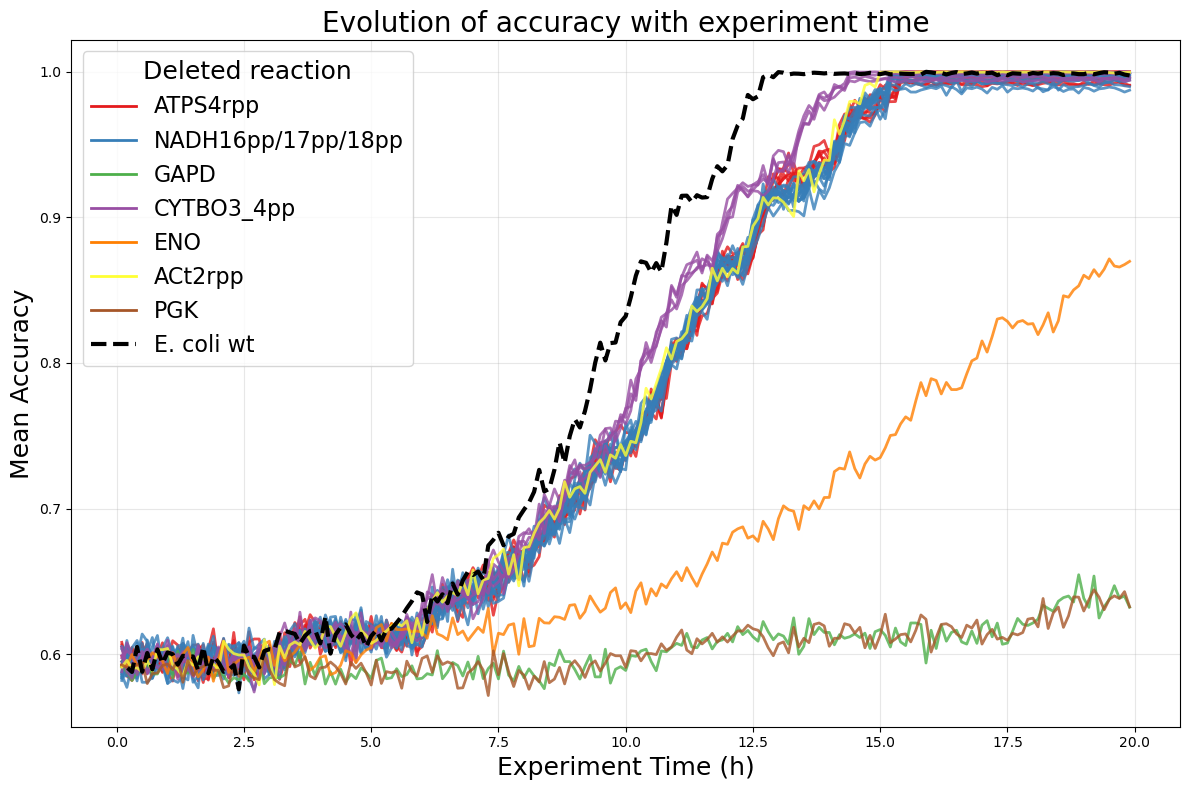

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict

std=False

# Read the CSV file to get reaction mappings
reactions_df = pd.read_csv("glc_xyl_mutants.txt", sep=',')
reaction_mapping = {}
for i, (_, row) in enumerate(reactions_df.iterrows()):
    mutant_id = i + 1  # mut_1.csv corresponds to line 1, mut_2.csv to line 2, etc.
    reaction = row['reaction']
    reaction_mapping[mutant_id] = reaction

# Get all files and process them
files = [fname for fname in os.listdir("tradeoff_analysis/iML1515_GX_muts") if fname.endswith(".csv")]
plt.figure(figsize=(12, 8))

# Color mapping for reactions
reaction_colors = {}
color_counter = 0
colors = plt.cm.Set1(np.linspace(0, 1, 9))  # Use Set1 colormap for distinct colors

# Store unique reactions and their mutant groups
reaction_mutants = defaultdict(list)

# Process each file to group mutants by reaction
for file in files:
    # Extract mutant number from filename (mut_1.csv, mut_2.csv, etc.)
    mutant_num = int(file.replace("mut_", "").replace(".csv", ""))
    
    # Get the reaction for this mutant from the mapping
    reaction = reaction_mapping.get(mutant_num, "Unknown")
    
    # Store the mutant with its reaction
    reaction_mutants[reaction].append((mutant_num, file))

# Create plots with grouped reactions
legend_handles = []
legend_labels = []

for reaction, mutants in reaction_mutants.items():
    # Assign color to this reaction
    if reaction not in reaction_colors:
        reaction_colors[reaction] = colors[color_counter % len(colors)]
        color_counter += 1
    
    # Plot all mutants from this reaction with the same color
    color = reaction_colors[reaction]
    
    # Create a list to store all mutant data for this reaction
    all_data = []
    
    # Process each mutant in this reaction group
    for mutant_num, file in mutants:
        results_df = pd.read_csv(f"tradeoff_analysis/iML1515_GX_muts/{file}")
        
        # Plot mean line
        plt.plot(results_df["remaining_timepoints"]/10, results_df["mean_acc_curves"], 
                linewidth=2, color=color, alpha=0.8)
        
        # Add shaded area for standard deviation
        if std:
            plt.fill_between(results_df["remaining_timepoints"]/10, 
                            results_df["mean_acc_curves"] - results_df["std_acc_curves"],
                            results_df["mean_acc_curves"] + results_df["std_acc_curves"],
                            alpha=0.2, color=color)
    
    # Add to legend with reaction name only (not the individual mutant names)
    legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=2))
    legend_labels.append(reaction)

wt_df = pd.read_csv("tradeoff_analysis/iML1515_GX.csv")

# Plot wild type line with different style
plt.plot(wt_df["remaining_timepoints"]/10, wt_df["mean_acc_curves"], 
            linewidth=3, linestyle='--', color='black', label='E. coli wt')

# Add shaded area for wild type standard deviation
if std:
    plt.fill_between(wt_df["remaining_timepoints"]/10, 
                    wt_df["mean_acc_curves"] - wt_df["std_acc_curves"],
                    wt_df["mean_acc_curves"] + wt_df["std_acc_curves"],
                    alpha=0.15, color='black')
    
legend_handles.append(plt.Line2D([0], [0], color='black', linewidth=3, linestyle='--'))
legend_labels.append('E. coli wt')

# Create the final plot
plt.xlabel("Experiment Time (h)", fontsize=18)
plt.ylabel("Mean Accuracy", fontsize=18)
plt.title("Evolution of accuracy with experiment time", fontsize=20)
plt.legend(legend_handles, legend_labels, loc='upper left', title='Deleted reaction', title_fontsize=18, fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
if std:
    plt.savefig('figures/acc_sd_muts_GX.pdf')
else:
    plt.savefig('figures/acc_muts_GX.pdf')
plt.show()

### Rank difference trajectory

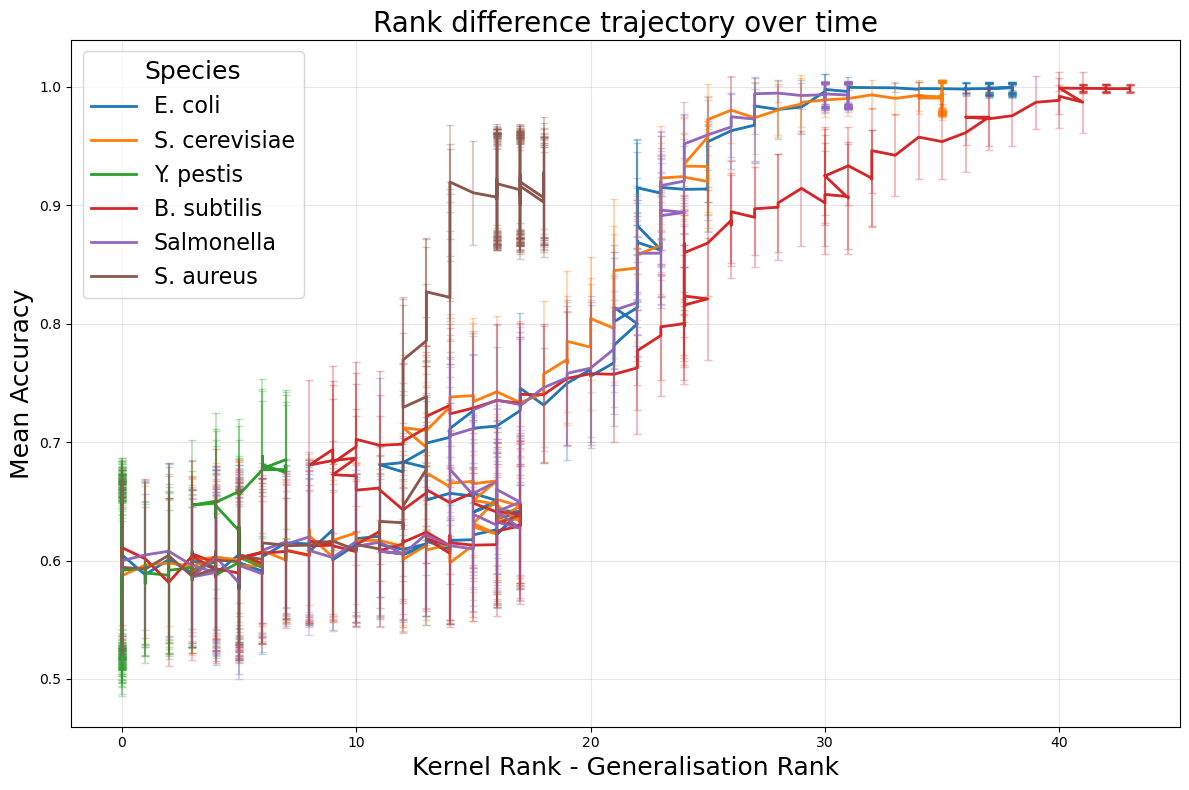

In [15]:
files = [fname for fname in os.listdir("tradeoff_analysis") if fname.endswith("GX.csv")]
plt.figure(figsize=(12, 8))
std=True

for file in files:
    results_df = pd.read_csv(f"tradeoff_analysis/{file}")
    # Extract model name
    model_name = file.strip("_GX.csv")

    kr_gr=results_df["ker_rank"]-results_df["gen_rank"]
    
    # Plot mean line
    line=plt.plot(kr_gr, results_df["mean_acc_curves"], 
             linewidth=2, label=species_names[model_name])
    
    # Add error bars for standard deviation
    if std:
        plt.errorbar(kr_gr, results_df["mean_acc_curves"],
            yerr=results_df["std_acc_curves"],
            capsize=3,
            alpha=0.3,
            linewidth=1.5,
            markersize=2,
            color=line[0].get_color(),
            zorder=2)

plt.xlabel("Kernel Rank - Generalisation Rank", fontsize=18)
plt.ylabel("Mean Accuracy", fontsize=18)
plt.title("Rank difference trajectory over time", fontsize=20)
plt.legend(loc='upper left', title='Species', title_fontsize=18, fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
if std:
    plt.savefig('figures/krgr_sd_species_GX.pdf')
else:
    plt.savefig('figures/krgr_species_GX.pdf')
plt.show()

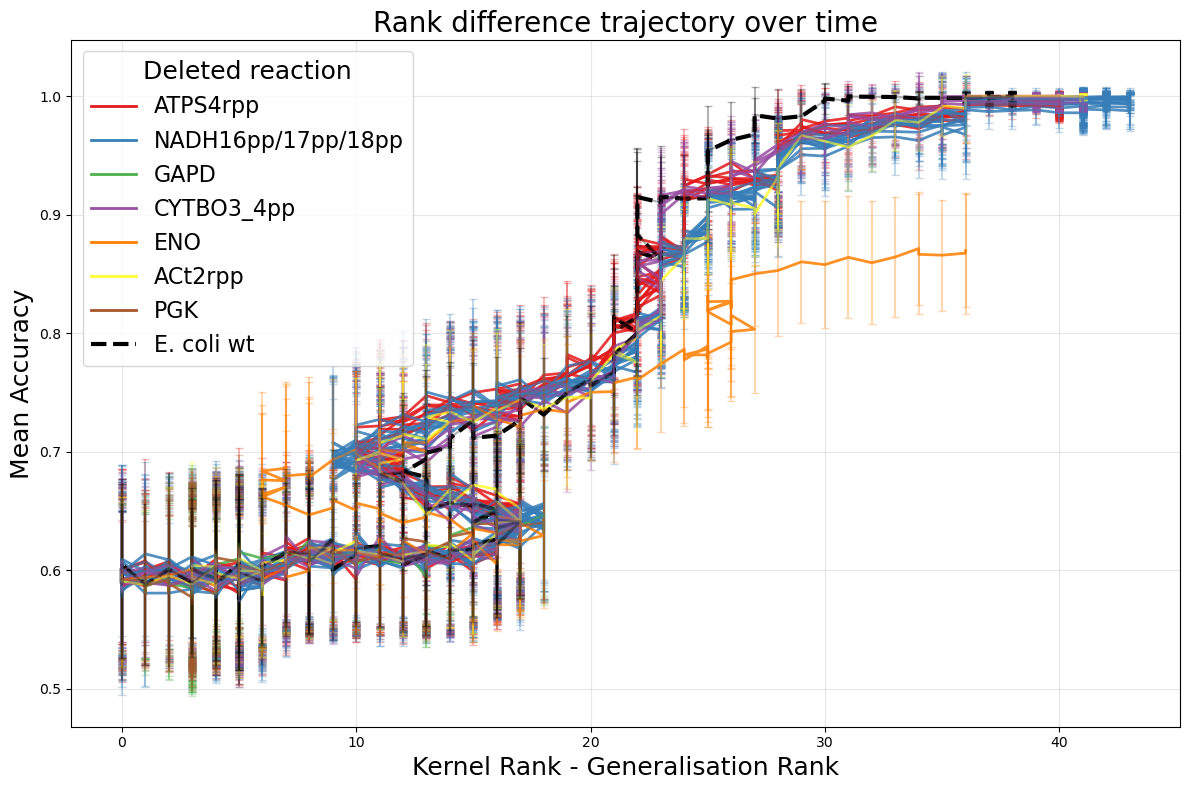

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import defaultdict

std=True

# Read the CSV file to get reaction mappings
reactions_df = pd.read_csv("glc_xyl_mutants.txt", sep=',')
reaction_mapping = {}
for i, (_, row) in enumerate(reactions_df.iterrows()):
    mutant_id = i + 1  # mut_1.csv corresponds to line 1, mut_2.csv to line 2, etc.
    reaction = row['reaction']
    reaction_mapping[mutant_id] = reaction

# Get all files and process them
files = [fname for fname in os.listdir("tradeoff_analysis/iML1515_GX_muts") if fname.endswith(".csv")]
plt.figure(figsize=(12, 8))

# Color mapping for reactions
reaction_colors = {}
color_counter = 0
colors = plt.cm.Set1(np.linspace(0, 1, 9))  # Use Set1 colormap for distinct colors

# Store unique reactions and their mutant groups
reaction_mutants = defaultdict(list)

# Process each file to group mutants by reaction
for file in files:
    # Extract mutant number from filename (mut_1.csv, mut_2.csv, etc.)
    mutant_num = int(file.replace("mut_", "").replace(".csv", ""))
    
    # Get the reaction for this mutant from the mapping
    reaction = reaction_mapping.get(mutant_num, "Unknown")
    
    # Store the mutant with its reaction
    reaction_mutants[reaction].append((mutant_num, file))

# Create plots with grouped reactions
legend_handles = []
legend_labels = []

for reaction, mutants in reaction_mutants.items():
    # Assign color to this reaction
    if reaction not in reaction_colors:
        reaction_colors[reaction] = colors[color_counter % len(colors)]
        color_counter += 1
    
    # Plot all mutants from this reaction with the same color
    color = reaction_colors[reaction]
    
    # Create a list to store all mutant data for this reaction
    all_data = []
    
    # Process each mutant in this reaction group
    for mutant_num, file in mutants:
        results_df = pd.read_csv(f"tradeoff_analysis/iML1515_GX_muts/{file}")

        kr_gr=results_df["ker_rank"]-results_df["gen_rank"]
        
        # Plot mean line
        line=plt.plot(kr_gr, results_df["mean_acc_curves"], 
                linewidth=2, color=color, alpha=0.8)
        
        # Add shaded area for standard deviation
        if std:
            plt.errorbar(kr_gr, results_df["mean_acc_curves"],
                yerr=results_df["std_acc_curves"],
                capsize=3,
                alpha=0.3,
                linewidth=1.5,
                markersize=2,
                color=line[0].get_color(),
                zorder=2)
    
    # add to legend with reaction name only (not the individual mutant names)
    legend_handles.append(plt.Line2D([0], [0], color=color, linewidth=2))
    legend_labels.append(reaction)

wt_df = pd.read_csv("tradeoff_analysis/iML1515_GX.csv")

kr_gr=wt_df["ker_rank"]-wt_df["gen_rank"]

# Plot wild type line with different style
line=plt.plot(kr_gr, wt_df["mean_acc_curves"], 
            linewidth=3, linestyle='--', color='black', label='E. coli wt')

# Add shaded area for wild type standard deviation
if std:
    plt.errorbar(kr_gr, wt_df["mean_acc_curves"],
                yerr=wt_df["std_acc_curves"],
                capsize=3,
                alpha=0.3,
                linewidth=1.5,
                markersize=2,
                color=line[0].get_color(),
                zorder=2)
    
legend_handles.append(plt.Line2D([0], [0], color='black', linewidth=3, linestyle='--'))
legend_labels.append('E. coli wt')

# Create the final plot
plt.xlabel("Kernel Rank - Generalisation Rank", fontsize=18)
plt.ylabel("Mean Accuracy", fontsize=18)
plt.title("Rank difference trajectory over time", fontsize=20)
plt.legend(legend_handles, legend_labels, loc='upper left', title='Deleted reaction', title_fontsize=18, fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
if std:
    plt.savefig('figures/krgr_sd_muts_GX.pdf')
else:
    plt.savefig('figures/krgr_muts_GX.pdf')
plt.show()

### Rank trajectories E. coli

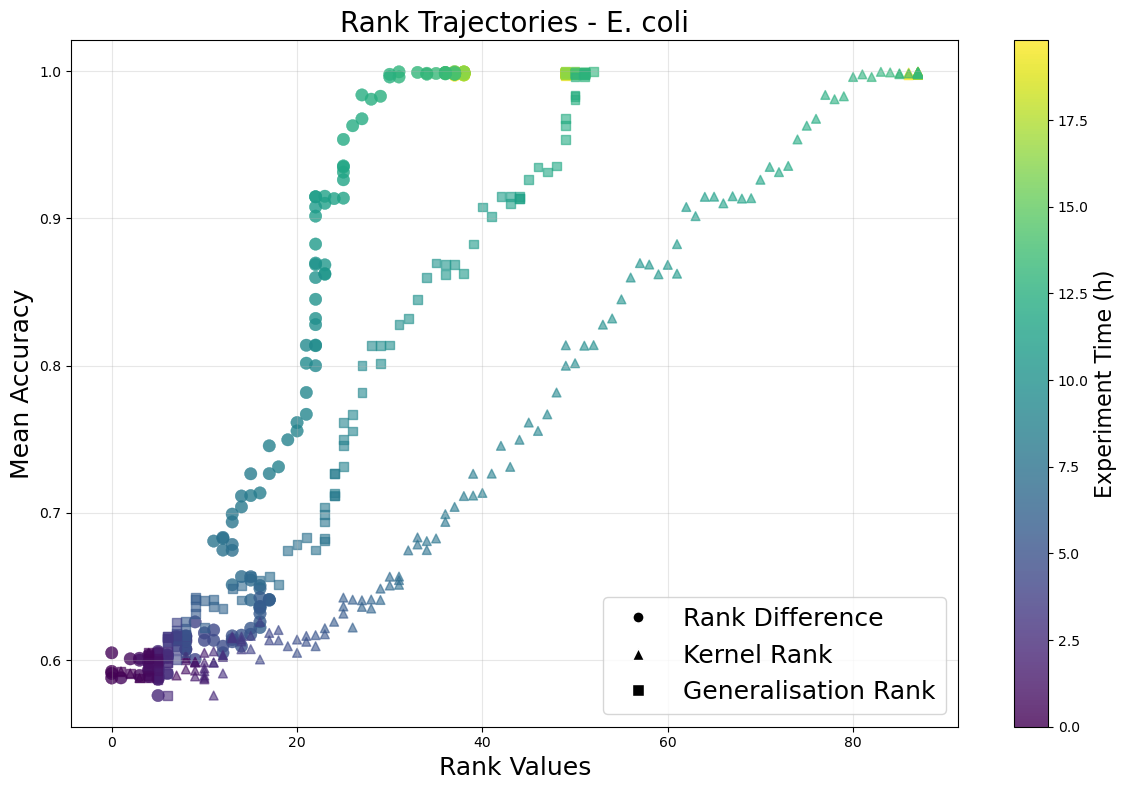

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the specific model file
file_name = 'iML1515_GX.csv'
results_df = pd.read_csv(f"tradeoff_analysis/{file_name}")


plt.figure(figsize=(12, 8))

# Plot kr-gr trajectory with time gradient
kr_gr_values = results_df["ker_rank"] - results_df["gen_rank"]
time_indices = np.arange(len(kr_gr_values))[::-1]/10

# Create scatter plot with time gradient
scatter = plt.scatter(kr_gr_values, results_df["mean_acc_curves"],
                     c=time_indices, cmap='viridis', s=80, alpha=0.8, linewidth=0.3)

# Add kr and gr points
plt.scatter(results_df["ker_rank"], results_df["mean_acc_curves"],
           c=time_indices, cmap='viridis', s=40, alpha=0.6, marker='^')

plt.scatter(results_df["gen_rank"], results_df["mean_acc_curves"],
           c=time_indices, cmap='viridis', s=40, alpha=0.6, marker='s')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Experiment Time (h)', fontsize=16)

# Add legend for the different markers
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=8, label='Rank Difference'),
                   Line2D([0], [0], marker='^', color='w', markerfacecolor='black', markersize=8, label='Kernel Rank'),
                   Line2D([0], [0], marker='s', color='w', markerfacecolor='black', markersize=8, label='Generalisation Rank')]

plt.xlabel("Rank Values", fontsize=18)
plt.ylabel("Mean Accuracy", fontsize=18)
plt.title(f"Rank Trajectories - E. coli", fontsize=20)
plt.legend(handles=legend_elements, loc='lower right', fontsize=18)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/rank_trajectories.pdf')
plt.show()

